In [64]:
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parent
DATA_PROCESSED = ROOT / "data" / "processed"

data = pd.read_csv(DATA_PROCESSED / "master.csv", index_col=0, parse_dates=True, skiprows=[1])
print(data.head())
print(data.dtypes)

                    spx        vix      vix3m
date                                         
2006-07-18  1236.859985  17.740000  17.219999
2006-07-19  1259.810059  15.550000  15.600000
2006-07-20  1249.130005  16.209999  16.309999
2006-07-21  1240.290039  17.400000  17.040001
2006-07-24  1260.910034  14.980000  15.410000
spx      float64
vix      float64
vix3m    float64
dtype: object


In [65]:
# Log returns on SPX
data["log_ret"] = np.log(data["spx"] / (data["spx"].shift(1)))

# 30-day rolling realised vol, annualised
data["rv_30"] = data["log_ret"].rolling(30).std() * np.sqrt(252)

print(f"RV mean: {data['rv_30'].mean():.4f}")
print(f"RV max: {data['rv_30'].max():.4f} (should be ~2008 crisis)")
print(f"RV min: {data['rv_30'].min():.4f}")

RV mean: 0.1638
RV max: 0.8587 (should be ~2008 crisis)
RV min: 0.0356


In [66]:
# VRP: implied vol minus realised vol
# divide VIX by 100 to match RV units
data["vrp"] = (data["vix"] / 100) - data["rv_30"]

# Term structure slope:
# Positive = contango (normal). Negative = backwardation (danger).
data["slope"] = (data["vix3m"] - data["vix"]) / data["vix"]

print(f"VRP mean:   {data['vrp'].mean():.4f}  (expect ~0.03–0.05)")
print(f"VRP min:    {data['vrp'].min():.4f}  (large negative = crisis)")
print(f"Slope mean: {data['slope'].mean():.4f}  (expect positive)")

VRP mean:   0.0329  (expect ~0.03–0.05)
VRP min:    -0.4677  (large negative = crisis)
Slope mean: 0.1094  (expect positive)


In [67]:
signals  = data[["spx", "vix", "vix3m", "rv_30", "vrp", "slope"]].dropna()
signals.to_csv(DATA_PROCESSED / "signals.csv")

print(f"Signals saved: {len(signals)} rows")
print(f"Dropped {len(data) - len(signals)} rows (RV warmup period, should be 30)")

Signals saved: 4964 rows
Dropped 30 rows (RV warmup period, should be 30)


Text(0.5, 1.0, 'S&P 500')

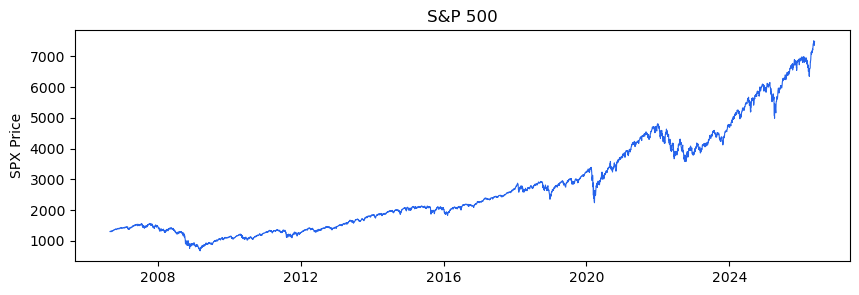

In [68]:
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates

signals = pd.read_csv(DATA_PROCESSED / "signals.csv", index_col=0, parse_dates=True)
# SPX Price Plot
fig, axes = plt.subplots(figsize=(10,3))
axes.plot(signals.index, signals["spx"], color="#2563eb", linewidth=0.8)
axes.set_ylabel("SPX Price")
axes.set_title("S&P 500")

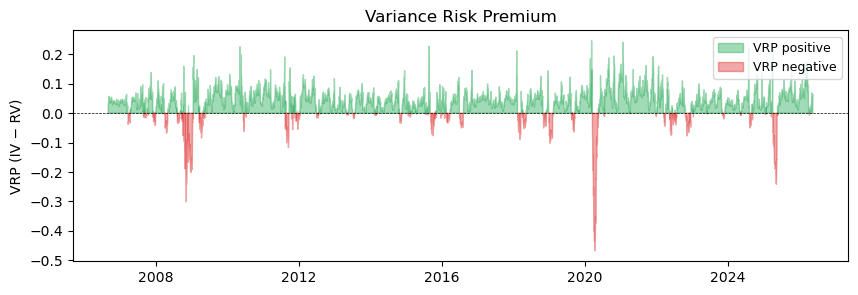

In [69]:
# Plot VRP over time:
fig, axes = plt.subplots(figsize=(10,3))
axes.fill_between(signals.index, signals["vrp"], 0,
                     where=signals["vrp"] >= 0, color="#16a34a", alpha=0.4, label="VRP positive")
axes.fill_between(signals.index, signals["vrp"], 0,
                     where=signals["vrp"] < 0, color="#dc2626", alpha=0.4, label="VRP negative")
axes.axhline(0, color="black", linewidth=0.5, linestyle="--")
axes.set_ylabel("VRP (IV − RV)")
axes.set_title("Variance Risk Premium")
axes.legend(loc="upper right", fontsize=9)

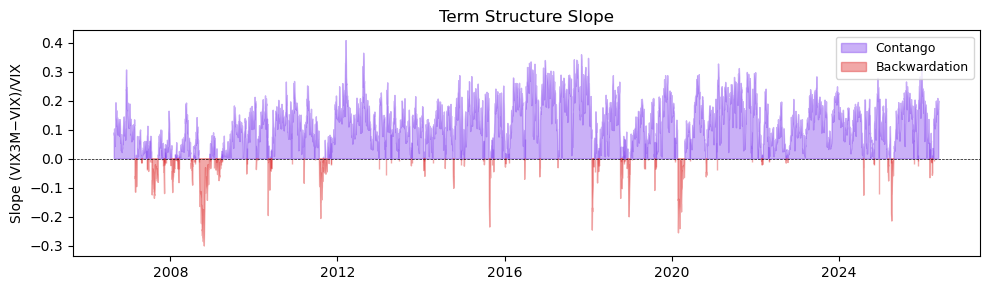

In [70]:
# Plot Term Structure Slope 
fig, axes = plt.subplots(figsize=(10,3))
axes.fill_between(signals.index, signals["slope"], 0,
                     where=signals["slope"] >= 0, color="#7c3aed", alpha=0.4, label="Contango")
axes.fill_between(signals.index, signals["slope"], 0,
                     where=signals["slope"] < 0, color="#dc2626", alpha=0.4, label="Backwardation")
axes.axhline(0, color="black", linewidth=0.5, linestyle="--")
axes.set_ylabel("Slope (VIX3M−VIX)/VIX")
axes.set_title("Term Structure Slope")
axes.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()